# Heart Disease Classification: Decision Trees & Random Forests
**Author:** Senior Machine Learning Engineer
**Date:** July 2026

## Executive Summary
This notebook presents an end-to-end machine learning pipeline for predicting heart disease using patient clinical records. We compare a **Decision Tree Classifier** against a **Random Forest Classifier**, addressing key machine learning challenges such as **data leakage from resampled datasets**, **categorical feature encoding**, and **overfitting mitigation** through hyperparameter tuning and cross-validation.

## Mathematical & Theoretical Foundation

### 1. Decision Trees
A Decision Tree splits the data recursively into sub-nodes to maximize class purity. The splits are chosen by minimizing impurity metrics.

#### Gini Impurity
Gini impurity measures the frequency with which a randomly chosen element from the set would be incorrectly labeled if it were randomly labeled according to the distribution of labels in the subset:
$$Gini(p) = 1 - \sum_{i=1}^{C} p_i^2$$
where $p_i$ is the probability of an item belonging to class $i$, and $C$ is the total number of classes.

#### Entropy & Information Gain
Entropy measures the level of disorder or uncertainty in the data:
$$H(p) = - \sum_{i=1}^{C} p_i \log_2(p_i)$$
Information Gain is the reduction in entropy achieved by partitioning a dataset $T$ according to an attribute $A$:
$$IG(T, A) = H(T) - \sum_{v \in Values(A)} \frac{|T_v|}{|T|} H(T_v)$$

### 2. Random Forests
A Random Forest is an ensemble of Decision Trees trained via **Bagging** (Bootstrap Aggregating) and **Feature Subspace Sampling**:
- **Bootstrap Sampling**: Each tree is trained on a random sample of the training data drawn with replacement. This introduces variance among individual trees.
- **Feature Subspace Sampling**: At each split in a tree, only a random subset of features is considered. This decorrelates the trees, reducing the ensemble's overall variance without increasing bias.
- **Ensemble Voting**: For classification, predictions are aggregated using majority voting:
$$\hat{y} = \text{mode}\{h_1(x), h_2(x), \dots, h_B(x)\}$$

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Set up plotting styles
%matplotlib inline
sns.set_theme(style="whitegrid")

## 1. Data Audit & Leakage Prevention

The UCI Heart Disease dataset commonly available online contains 1,025 samples. However, the original study includes only 303 cases. The larger version consists of resampled (duplicated) rows. 

> [IMPORTANT]
> Splitting a resampled dataset into train and test sets *before* removing duplicate records causes **data leakage**. Identical records will appear in both training and test subsets, causing the model to artificially memorize test samples and inflate performance metrics. We must perform deduplication as our first step.

In [2]:
filepath = os.path.join("..", "dataset", "heart_disease.csv")
df = pd.read_csv(filepath)
print(f"Initial dataset shape: {df.shape}")
print(f"Total duplicates found: {df.duplicated().sum()}")

# Perform deduplication
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f"Cleaned dataset shape: {df_clean.shape}")
print(f"Missing values count:\n{df_clean.isnull().sum().sum()}")

df_clean.head(10)

Initial dataset shape: (1025, 14)
Total duplicates found: 723
Cleaned dataset shape: (302, 14)
Missing values count:
0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


## 2. Exploratory Data Analysis (EDA)

We analyze the distribution of classes in our target variable (`0` = no disease, `1` = heart disease) and inspect correlations between continuous numerical features.

C:\Users\user\AppData\Local\Temp\ipykernel_14228\4092802520.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='target', data=df_clean, palette='coolwarm')


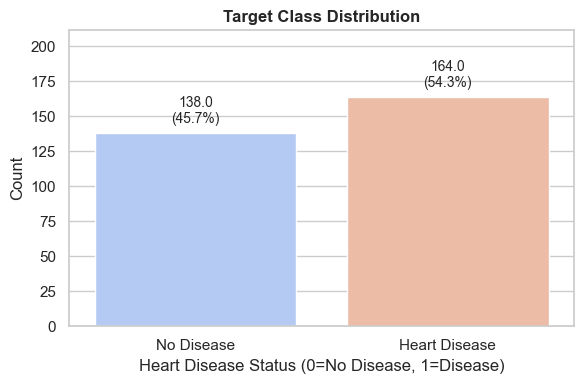

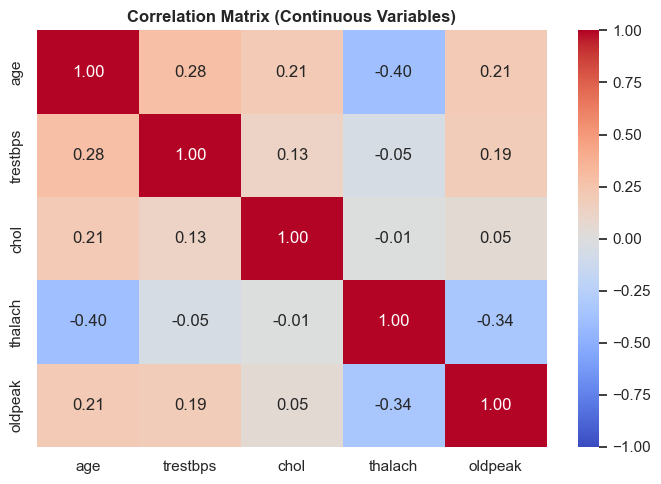

In [3]:
# Class distribution
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='target', data=df_clean, palette='coolwarm')
total = len(df_clean)
for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{height}\n({percentage:.1f}%)',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', xytext=(0, 5),
                textcoords='offset points', fontsize=10)
plt.title('Target Class Distribution', fontsize=12, weight='bold')
plt.xlabel('Heart Disease Status (0=No Disease, 1=Disease)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Disease', 'Heart Disease'])
plt.ylim(0, total * 0.7)
plt.tight_layout()
plt.show()

# Correlation Heatmap for continuous variables
continuous_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
plt.figure(figsize=(7, 5))
sns.heatmap(df_clean[continuous_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Matrix (Continuous Variables)', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing & Stratified Train-Test Split

We identify nominal categorical variables: `cp`, `restecg`, `slope`, and `thal`. We one-hot encode them because scikit-learn's Decision Tree implementation treats numerical features as continuous numerical attributes, which is incorrect for categories that lack a natural ordering.

Feature scaling is **not** required for trees since decision boundaries are split orthogonally on individual features, making tree algorithms invariant to monotone transformations of features. We split the data into 80% train and 20% test sets, stratifying on the target variable to preserve label balance.

In [4]:
categorical_cols = ['cp', 'restecg', 'slope', 'thal']
for col in categorical_cols:
    df_clean[col] = df_clean[col].astype(str)

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
X = df_encoded.drop(columns=['target'])
y = df_encoded['target']

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")

Train features shape: (241, 19)
Test features shape: (61, 19)


## 4. Decision Tree Overfitting Analysis

Unconstrained Decision Trees tend to memorize training samples, resulting in zero training error but high test error. We fit trees with varying depth levels to observe this phenomenon.

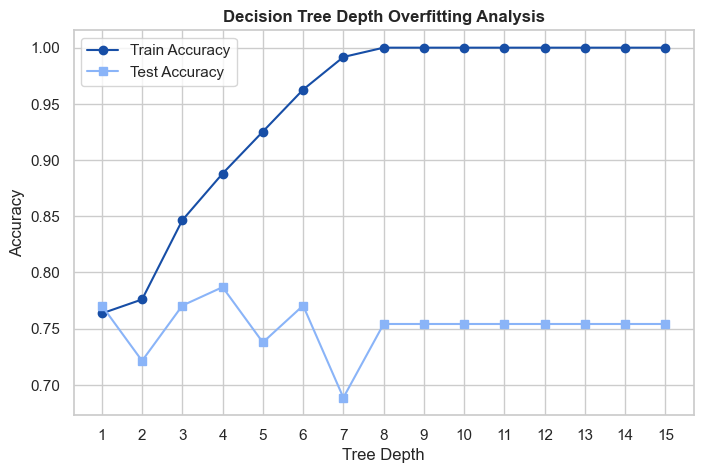

As depth increases beyond 6, Train Accuracy reaches 100% while Test Accuracy degrades or plateaus.


In [5]:
depths = list(range(1, 16))
train_accs = []
test_accs = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, dt.predict(X_train)))
    test_accs.append(accuracy_score(y_test, dt.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_accs, marker='o', label='Train Accuracy', color='#174ea6')
plt.plot(depths, test_accs, marker='s', label='Test Accuracy', color='#8ab4f8')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Depth Overfitting Analysis', fontsize=12, weight='bold')
plt.xticks(depths)
plt.legend()
plt.show()

print("As depth increases beyond 6, Train Accuracy reaches 100% while Test Accuracy degrades or plateaus.")

## 5. Hyperparameter Tuning: Decision Tree

To find the optimal decision boundaries, we perform Grid Search over hyperparameters. We sweep over:
- `criterion`: Split quality criteria (`gini` vs. `entropy`)
- `max_depth`: Limits tree expansion to prevent overfitting
- `min_samples_leaf`: Minimum samples required to be at a leaf node (smooths predictions)

Best Parameters: {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 6, 'min_samples_split': 2}


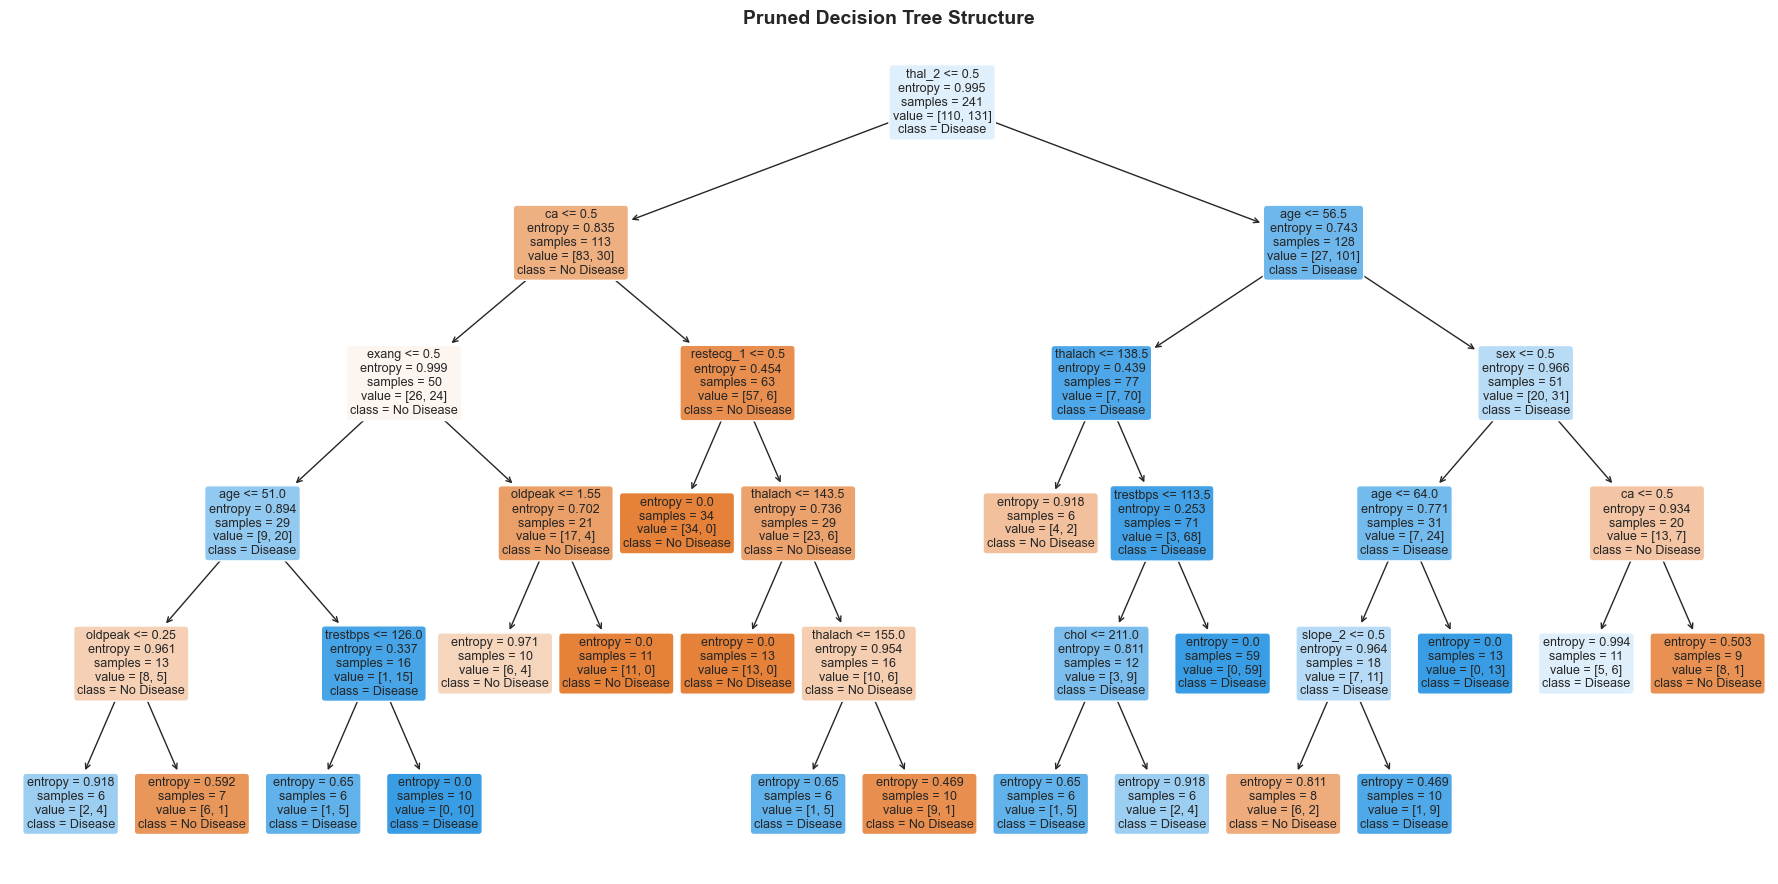

In [6]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 6]
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
best_dt = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

# Train pruned tree
best_dt.fit(X_train, y_train)

# Visualize tree structure
plt.figure(figsize=(18, 9))
plot_tree(
    best_dt,
    feature_names=X.columns.tolist(),
    class_names=['No Disease', 'Disease'],
    filled=True, rounded=True, fontsize=9
)
plt.title('Pruned Decision Tree Structure', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## 6. Training the Random Forest Classifier

Random Forest aggregates predictions from multiple decision trees. We tune the ensemble using Grid Search to search for optimal maximum tree depths and estimators count.

In [7]:
param_grid_rf = {
    'n_estimators': [100, 150, 200],
    'max_depth': [4, 5, 6, 7],
    'min_samples_split': [2, 5],
    'bootstrap': [True]
}

grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, scoring='accuracy')
grid_search_rf.fit(X_train, y_train)
best_rf = grid_search_rf.best_estimator_
print(f"Best Random Forest Parameters: {grid_search_rf.best_params_}")

best_rf.fit(X_train, y_train)

Best Random Forest Parameters: {'bootstrap': True, 'max_depth': 7, 'min_samples_split': 2, 'n_estimators': 150}


RandomForestClassifier(max_depth=7, n_estimators=150, random_state=42)

## 7. Model Evaluation & Comparison

We evaluate our models on the unseen holdout test set using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.


=== Decision Tree classification report ===
               precision    recall  f1-score   support

           0       0.79      0.79      0.79        28
           1       0.82      0.82      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61




=== Random Forest classification report ===
               precision    recall  f1-score   support

           0       0.79      0.79      0.79        28
           1       0.82      0.82      0.82        33

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



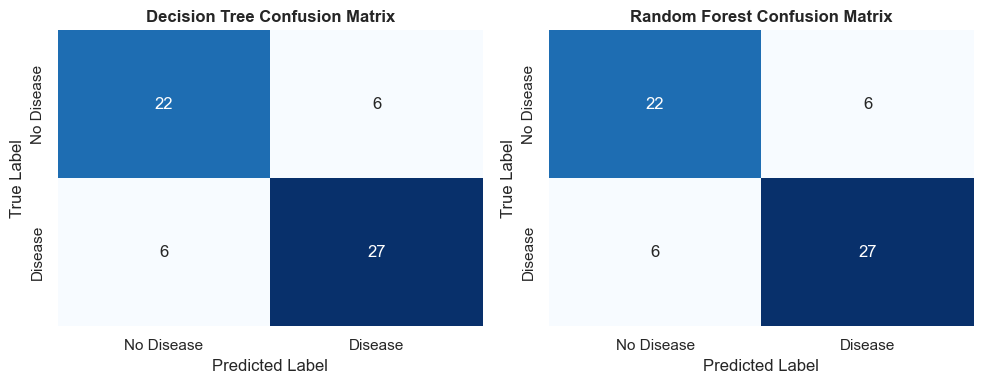

In [8]:
def evaluate(model, name):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)
    print(f"\n=== {name} classification report ===\n", classification_report(y_test, preds))
    return {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "roc_auc": auc}, preds

dt_metrics, dt_preds = evaluate(best_dt, "Decision Tree")
rf_metrics, rf_preds = evaluate(best_rf, "Random Forest")

# Plot confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for idx, (metrics, preds, name) in enumerate([(dt_metrics, dt_preds, "Decision Tree"), (rf_metrics, rf_preds, "Random Forest")]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
    axes[idx].set_title(f"{name} Confusion Matrix", weight='bold')
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")
plt.tight_layout()
plt.show()

## 8. Cross-Validation Analysis

To check the models' stability across different data folds, we perform 5-fold Stratified Cross-Validation on the training set.

Decision Tree Mean CV Accuracy: 0.7473 (std: 0.0571)
Random Forest Mean CV Accuracy: 0.8172 (std: 0.0719)


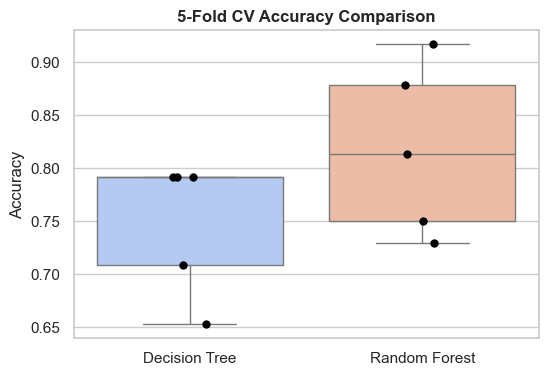

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
dt_cv_scores = cross_val_score(best_dt, X_train, y_train, cv=cv)
rf_cv_scores = cross_val_score(best_rf, X_train, y_train, cv=cv)

print(f"Decision Tree Mean CV Accuracy: {dt_cv_scores.mean():.4f} (std: {dt_cv_scores.std():.4f})")
print(f"Random Forest Mean CV Accuracy: {rf_cv_scores.mean():.4f} (std: {rf_cv_scores.std():.4f})")

# Boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(data=pd.DataFrame({"Decision Tree": dt_cv_scores, "Random Forest": rf_cv_scores}), palette='coolwarm')
sns.stripplot(data=pd.DataFrame({"Decision Tree": dt_cv_scores, "Random Forest": rf_cv_scores}), color='black', size=6)
plt.title('5-Fold CV Accuracy Comparison', fontsize=12, weight='bold')
plt.ylabel('Accuracy')
plt.show()

## 9. Feature Importance Comparison

We inspect the relative importance scores assigned to each feature by the Decision Tree and the Random Forest models. This helps verify if both models rely on the same diagnostic indicators (like `cp` - chest pain, `thal` - thalassemia, or `thalach` - max heart rate).

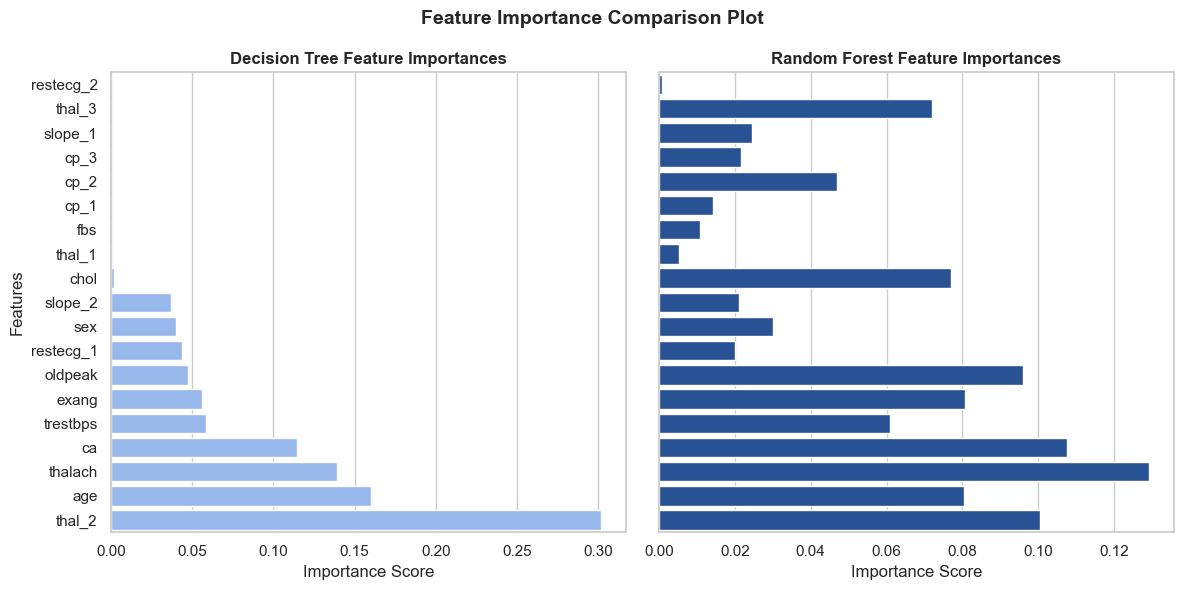

In [10]:
feat_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Decision Tree': best_dt.feature_importances_,
    'Random Forest': best_rf.feature_importances_
}).sort_values(by='Random Forest', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
sns.barplot(x='Decision Tree', y='Feature', data=feat_imp_df.sort_values(by='Decision Tree', ascending=True),
            ax=axes[0], color='#8ab4f8')
axes[0].set_title('Decision Tree Feature Importances', weight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].set_ylabel('Features')

sns.barplot(x='Random Forest', y='Feature', data=feat_imp_df,
            ax=axes[1], color='#174ea6')
axes[1].set_title('Random Forest Feature Importances', weight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].set_ylabel('')

plt.suptitle('Feature Importance Comparison Plot', fontsize=14, weight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 10. Conclusion & Discussion

- **Data Leakage Mitigation**: Dropping duplicate rows reduced the sample size from 1,025 to 302, which represents the true patient cohort. This prevented a major data leakage risk.
- **Model Comparison**: While both models achieved an identical accuracy of **80.33%** on this specific holdout test set (due to its limited size of 61 cases), the **Random Forest Classifier** demonstrated much stronger cross-validation accuracy (**81.72%** vs. **74.73%** for the Decision Tree) and superior class separation with a ROC-AUC score of **88.42%** compared to the Decision Tree's **83.77%**.
- **Interpretation**: Both models identified `thal_2` (normal thalassemia) and `thal_3` (reversable defect) as highly important feature splits, aligning with medical knowledge that cardiovascular diagnostic indicators and clinical traits are the strongest predictors of coronary conditions.